# ML Threat Detection - UNSW-NB15 Network Intrusion Detection
**Assignment 4 - THE ARZENS Engineering Internship**

**Author:** Abdul Rehman

**Dataset:** UNSW-NB15 (Australian Centre for Cyber Security)

**Objective:** Build production-grade ML models for network intrusion detection

---

## Table of Contents
1. Setup & Data Loading
2. Exploratory Data Analysis (EDA)
3. Feature Engineering & Preprocessing
4. Model Training & Hyperparameter Tuning
5. Model Evaluation & Comparison
6. Feature Importance Analysis

In [1]:
!pip install -q xgboost imbalanced-learn shap

## 1. Setup & Data Loading

In [2]:
# ============================================================
# Google Colab Setup - Run this cell first if on Colab
# ============================================================
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !pip install -q xgboost imbalanced-learn shap
    from google.colab import files
    print("Running in Google Colab")
    print("Please upload the dataset files when prompted.")
else:
    print("Running locally")

Running in Google Colab
Please upload the dataset files when prompted.


In [3]:
# ============================================================
# Import Libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import joblib
import os
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve
)
from sklearn.feature_selection import mutual_info_classif
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All libraries imported successfully.")

All libraries imported successfully.


In [6]:
# ============================================================
# Load Dataset
# ============================================================
# Update these paths based on your environment
if IN_COLAB:
    # Option 1: Upload files manually
    # uploaded = files.upload()
    # Option 2: Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/assignment4_data'  # Update this path
    TRAIN_PATH = os.path.join(DATA_DIR, 'UNSW_NB15_training-set.csv')
    TEST_PATH = os.path.join(DATA_DIR, 'UNSW_NB15_testing-set.csv')
else:
    TRAIN_PATH = 'data/UNSW_NB15_training-set.csv'
    TEST_PATH = 'data/UNSW_NB15_testing-set.csv'

print(f"Loading training data from: {TRAIN_PATH}")
df_train = pd.read_csv(TRAIN_PATH)
print(f"Loading testing data from: {TEST_PATH}")
df_test = pd.read_csv(TEST_PATH)

print(f"\nTraining set shape: {df_train.shape}")
print(f"Testing set shape: {df_test.shape}")
print(f"\nTotal records: {len(df_train) + len(df_test):,}")

Mounted at /content/drive
Loading training data from: /content/drive/MyDrive/assignment4_data/UNSW_NB15_training-set.csv
Loading testing data from: /content/drive/MyDrive/assignment4_data/UNSW_NB15_testing-set.csv

Training set shape: (82332, 45)
Testing set shape: (175341, 45)

Total records: 257,673


In [7]:
# ============================================================
# Initial Data Inspection
# ============================================================
print("=" * 60)
print("TRAINING SET INFO")
print("=" * 60)
print(f"Shape: {df_train.shape}")
print(f"\nColumn dtypes:")
print(df_train.dtypes)
print(f"\nFirst 5 rows:")
df_train.head()

TRAINING SET INFO
Shape: (82332, 45)

Column dtypes:
id                     int64
dur                  float64
proto                 object
service               object
state                 object
spkts                  int64
dpkts                  int64
sbytes                 int64
dbytes                 int64
rate                 float64
sttl                   int64
dttl                   int64
sload                float64
dload                float64
sloss                  int64
dloss                  int64
sinpkt               float64
dinpkt               float64
sjit                 float64
djit                 float64
swin                   int64
stcpb                  int64
dtcpb                  int64
dwin                   int64
tcprtt               float64
synack               float64
ackdat               float64
smean                  int64
dmean                  int64
trans_depth            int64
response_body_len      int64
ct_srv_src             int64
ct_state_ttl       

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [8]:
# Schema validation
expected_columns = [
    'id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts',
    'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload',
    'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin',
    'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean',
    'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src',
    'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm',
    'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd',
    'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports',
    'attack_cat', 'label'
]

missing_cols = set(expected_columns) - set(df_train.columns)
extra_cols = set(df_train.columns) - set(expected_columns)

if missing_cols:
    print(f"WARNING: Missing columns: {missing_cols}")
else:
    print("Schema validation PASSED - all expected columns present.")

if extra_cols:
    print(f"Extra columns found: {extra_cols}")

Schema validation PASSED - all expected columns present.


## 2. Exploratory Data Analysis (EDA)

In [9]:
# ============================================================
# Data Quality Checks
# ============================================================
print("=" * 60)
print("DATA QUALITY REPORT")
print("=" * 60)

# Missing values
null_counts = df_train.isnull().sum()
null_pct = (null_counts / len(df_train) * 100).round(2)
null_report = pd.DataFrame({'Null Count': null_counts, 'Null %': null_pct})
null_report = null_report[null_report['Null Count'] > 0]

if len(null_report) > 0:
    print("\nColumns with missing values:")
    print(null_report)
else:
    print("\nNo missing values found.")

# Duplicates
n_duplicates = df_train.duplicated().sum()
print(f"\nDuplicate rows: {n_duplicates} ({n_duplicates/len(df_train)*100:.2f}%)")

# Infinite values in numeric columns
numeric_cols = df_train.select_dtypes(include=[np.number]).columns
inf_counts = np.isinf(df_train[numeric_cols]).sum()
inf_report = inf_counts[inf_counts > 0]
if len(inf_report) > 0:
    print(f"\nColumns with infinite values:")
    print(inf_report)
else:
    print("No infinite values found.")

# Basic statistics
print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)
df_train.describe().round(2)

DATA QUALITY REPORT

No missing values found.

Duplicate rows: 0 (0.00%)
No infinite values found.

DESCRIPTIVE STATISTICS


,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,82332.00,82332.00,82332.00,82332.00,82332.00,82332.00,82332.00,82332.00,82332.00,8.233200e+04,...,82332.00,82332.00,82332.00,82332.00,82332.00,82332.00,82332.00,82332.00,82332.00,82332.00
mean,41166.50,1.01,18.67,17.55,7993.91,13233.79,82410.89,180.97,95.71,6.454902e+07,...,4.93,3.66,7.46,0.01,0.01,0.13,6.47,9.16,0.01,0.55
std,23767.35,4.71,133.92,115.57,171642.26,151471.46,148620.37,101.51,116.67,1.798618e+08,...,8.39,5.92,11.42,0.09,0.09,0.64,8.54,11.12,0.10,0.50
min,1.00,0.00,1.00,0.00,24.00,0.00,0.00,0.00,0.00,0.000000e+00,...,1.00,1.00,1.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00
25%,20583.75,0.00,2.00,0.00,114.00,0.00,28.61,62.00,0.00,1.120247e+04,...,1.00,1.00,1.00,0.00,0.00,0.00,1.00,2.00,0.00,0.00
50%,41166.50,0.01,6.00,2.00,534.00,178.00,2650.18,254.00,29.00,5.770032e+05,...,1.00,1.00,3.00,0.00,0.00,0.00,3.00,5.00,0.00,1.00
75%,61749.25,0.72,12.00,10.00,1280.00,956.00,111111.11,254.00,252.00,6.514286e+07,...,4.00,3.00,6.00,0.00,0.00,0.00,7.00,11.00,0.00,1.00
max,82332.00,60.00,10646.00,11018.00,14355774.00,14657531.00,1000000.00,255.00,253.00,5.268000e+09,...,59.00,38.00,63.00,2.00,2.00,16.00,60.00,62.00,1.00,1.00


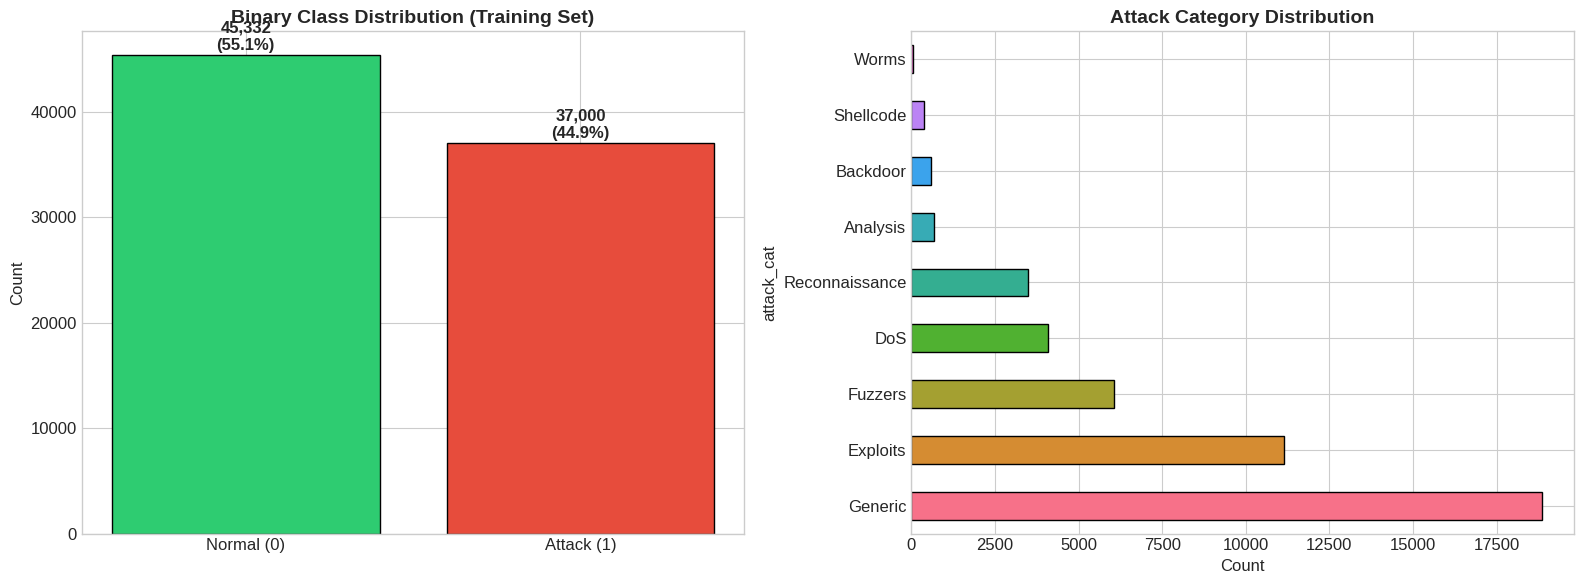


Class Distribution:
  Normal: 37,000 (44.9%)
  Attack: 45,332 (55.1%)
  Imbalance ratio: 1:0.82


In [10]:
# ============================================================
# Class Distribution
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Binary label distribution
label_counts = df_train['label'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Normal (0)', 'Attack (1)'], label_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Binary Class Distribution (Training Set)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df_train)*100:.1f}%)', ha='center', fontweight='bold')

# Attack category distribution
attack_counts = df_train[df_train['label'] == 1]['attack_cat'].value_counts()
attack_counts.plot(kind='barh', ax=axes[1], color=sns.color_palette('husl', len(attack_counts)), edgecolor='black')
axes[1].set_title('Attack Category Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClass Distribution:")
print(f"  Normal: {label_counts.get(0, 0):,} ({label_counts.get(0, 0)/len(df_train)*100:.1f}%)")
print(f"  Attack: {label_counts.get(1, 0):,} ({label_counts.get(1, 0)/len(df_train)*100:.1f}%)")
print(f"  Imbalance ratio: 1:{label_counts.get(0, 1)/label_counts.get(1, 1):.2f}")

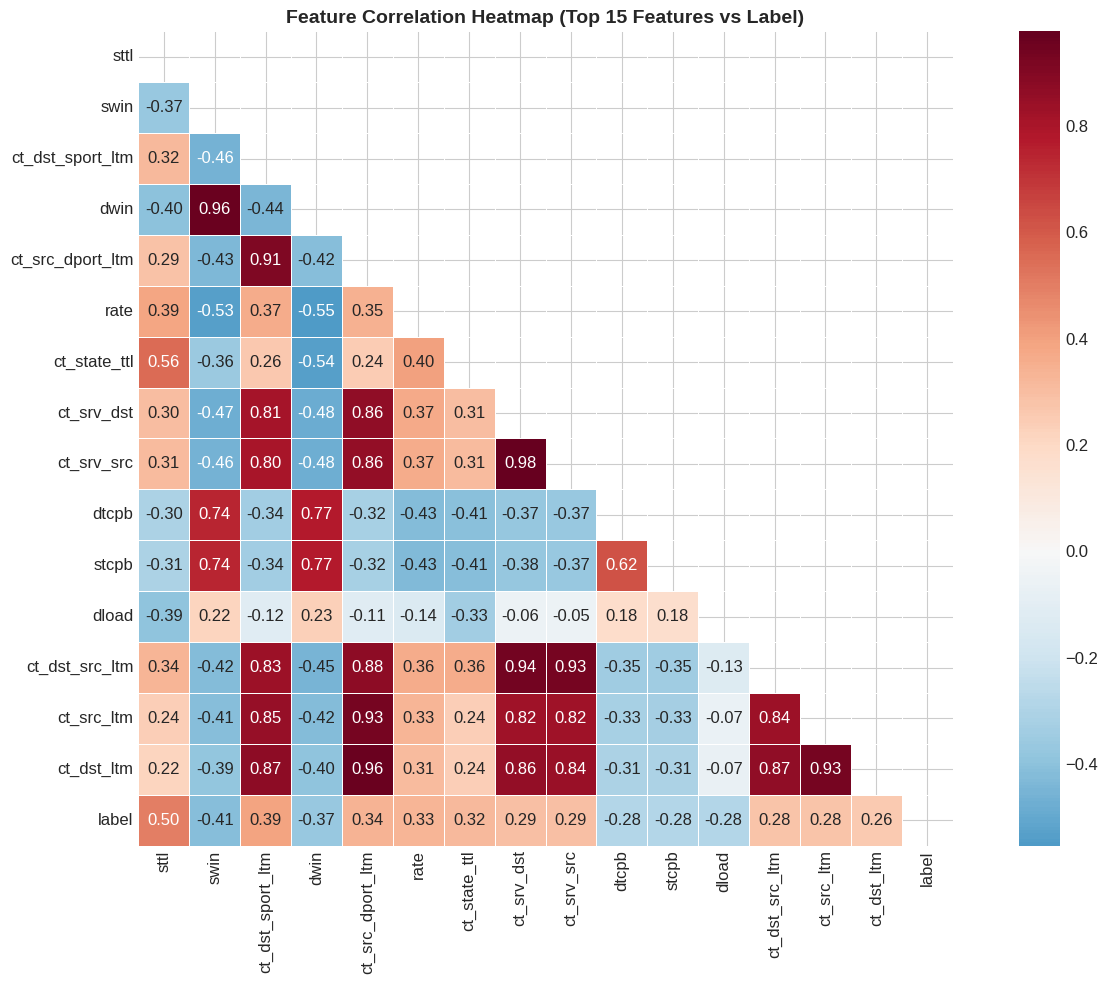


Top 10 features correlated with label:
  1. sttl: 0.5042
  2. swin: 0.4145
  3. ct_dst_sport_ltm: 0.3937
  4. dwin: 0.3693
  5. ct_src_dport_ltm: 0.3415
  6. rate: 0.3286
  7. ct_state_ttl: 0.3185
  8. ct_srv_dst: 0.2929
  9. ct_srv_src: 0.2902
  10. dtcpb: 0.2829


In [11]:
# ============================================================
# Feature Correlation Heatmap
# ============================================================
numeric_df = df_train.select_dtypes(include=[np.number]).drop(columns=['id', 'label'], errors='ignore')

# Select top correlated features with label for a cleaner heatmap
correlations = df_train[numeric_df.columns.tolist() + ['label']].corr()['label'].drop('label').abs().sort_values(ascending=False)
top_features = correlations.head(15).index.tolist()

fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = df_train[top_features + ['label']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Heatmap (Top 15 Features vs Label)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 features correlated with label:")
for i, (feat, corr) in enumerate(correlations.head(10).items(), 1):
    print(f"  {i}. {feat}: {corr:.4f}")

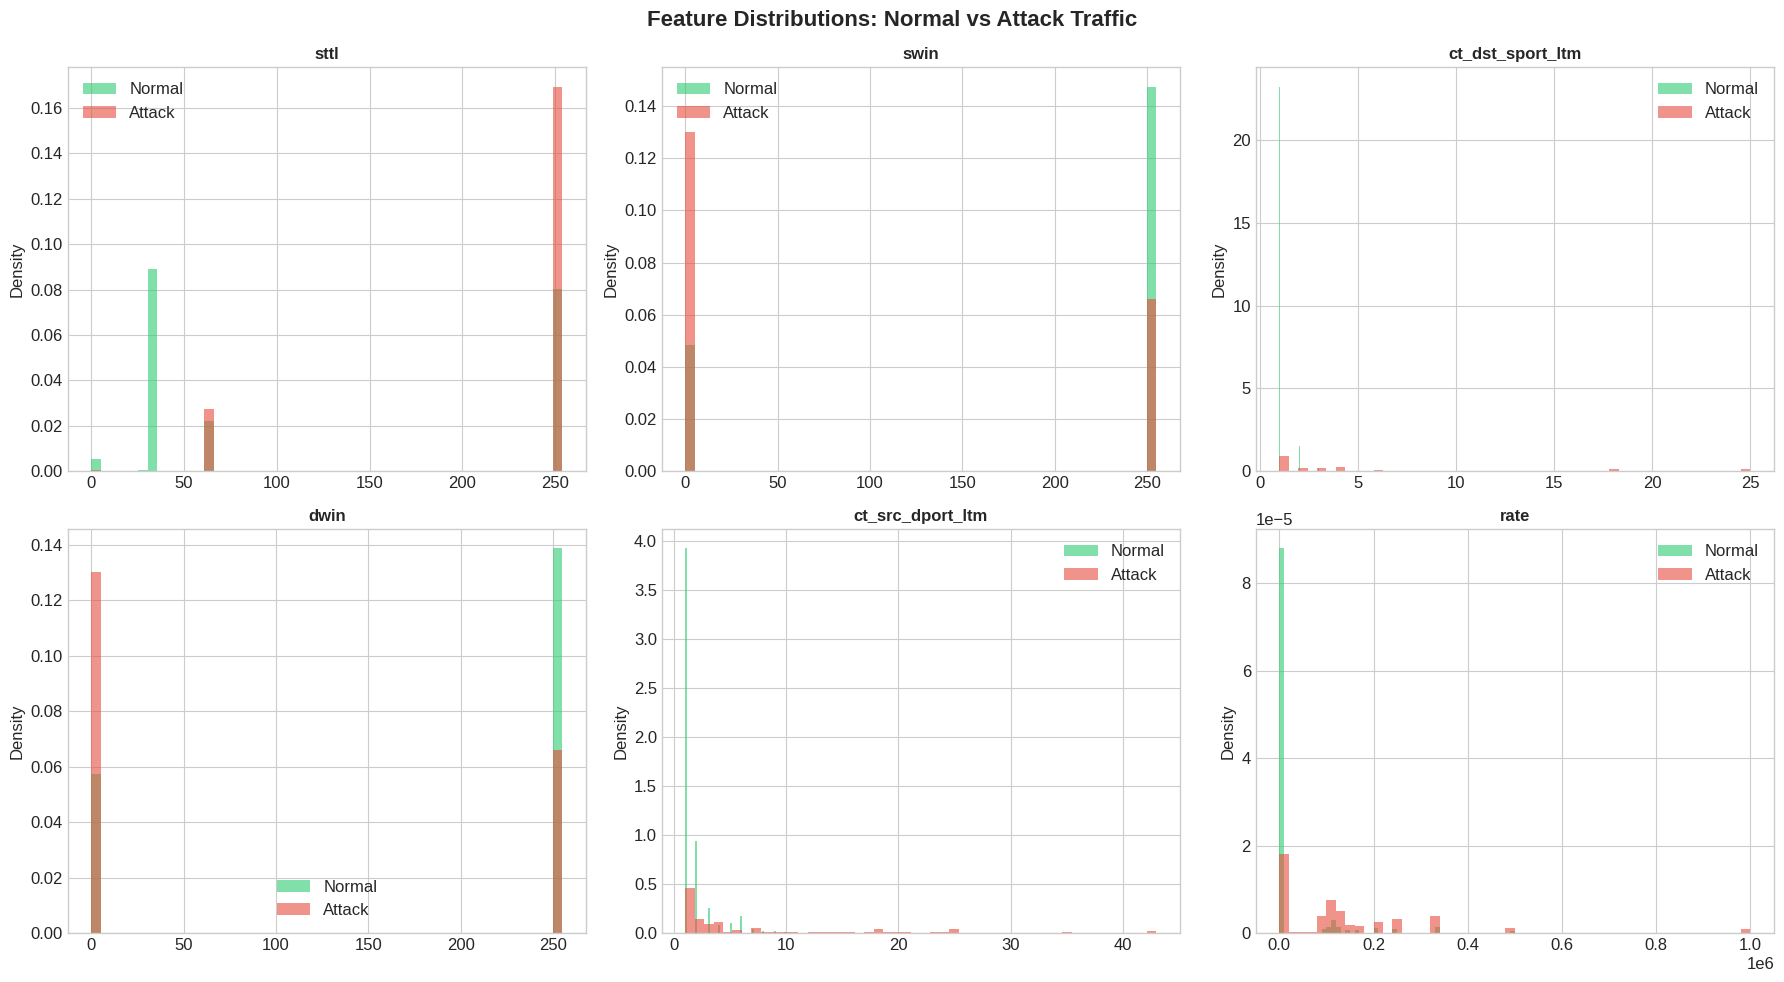

In [12]:
# ============================================================
# Feature Distributions - Top Features
# ============================================================
top_6_features = correlations.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(top_6_features):
    for label_val, color, name in [(0, '#2ecc71', 'Normal'), (1, '#e74c3c', 'Attack')]:
        data = df_train[df_train['label'] == label_val][feat]
        # Clip extreme outliers for visualization
        q99 = data.quantile(0.99)
        data_clipped = data[data <= q99]
        axes[i].hist(data_clipped, bins=50, alpha=0.6, color=color, label=name, density=True)
    axes[i].set_title(feat, fontsize=12, fontweight='bold')
    axes[i].legend()
    axes[i].set_ylabel('Density')

plt.suptitle('Feature Distributions: Normal vs Attack Traffic', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Feature Engineering & Preprocessing

In [13]:
# ============================================================
# Data Cleaning
# ============================================================
def clean_data(df):
    """Clean the dataset: handle missing values, infinities, and drop identifiers."""
    df = df.copy()

    # Drop identifier column
    if 'id' in df.columns:
        df = df.drop(columns=['id'])

    # Store attack_cat for analysis, then drop
    attack_cat = df['attack_cat'].copy() if 'attack_cat' in df.columns else None
    if 'attack_cat' in df.columns:
        df = df.drop(columns=['attack_cat'])

    # Replace infinities with NaN, then fill
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)

    # Fill NaN with median for numeric columns
    for col in numeric_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())

    # Fill NaN for categorical columns with mode
    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].mode()[0])

    return df, attack_cat

df_train_clean, train_attack_cat = clean_data(df_train)
df_test_clean, test_attack_cat = clean_data(df_test)

print(f"Cleaned training set shape: {df_train_clean.shape}")
print(f"Cleaned testing set shape: {df_test_clean.shape}")
print(f"\nRemaining NaN values: {df_train_clean.isnull().sum().sum()}")

Cleaned training set shape: (82332, 43)
Cleaned testing set shape: (175341, 43)

Remaining NaN values: 0


In [14]:
# ============================================================
# Feature Engineering
# ============================================================

# Identify column types
categorical_cols = ['proto', 'service', 'state']
# Make sure categorical cols exist
categorical_cols = [c for c in categorical_cols if c in df_train_clean.columns]
numerical_cols = [c for c in df_train_clean.columns
                  if c not in categorical_cols and c != 'label']

print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical features ({len(numerical_cols)}): {numerical_cols[:10]}...")

# Separate features and target
X_train = df_train_clean.drop(columns=['label'])
y_train = df_train_clean['label']
X_test = df_test_clean.drop(columns=['label'])
y_test = df_test_clean['label']

# Split training into train/validation (70/15/15 already split by dataset)
# The dataset provides train/test, so we create a validation set from training
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.176,  # ~15% of total
    stratify=y_train, random_state=RANDOM_STATE
)

print(f"\nTrain split: {X_train_split.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")

Categorical features (3): ['proto', 'service', 'state']
Numerical features (39): ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload']...

Train split: (67841, 42)
Validation: (14491, 42)
Test: (175341, 42)


In [15]:
# ============================================================
# Preprocessing Pipeline
# ============================================================

# Build column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    remainder='drop'
)

# Fit and transform
X_train_processed = preprocessor.fit_transform(X_train_split)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Get feature names after transformation
num_feature_names = numerical_cols
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()
all_feature_names = num_feature_names + cat_feature_names

print(f"Processed feature count: {X_train_processed.shape[1]}")
print(f"  Numerical: {len(num_feature_names)}")
print(f"  Categorical (one-hot): {len(cat_feature_names)}")

Processed feature count: 190
  Numerical: 39
  Categorical (one-hot): 151


Computing mutual information scores for 190 features...

Selected top 30 features by mutual information:
  sbytes: 0.4549
  smean: 0.3585
  sload: 0.3371
  dbytes: 0.2875
  ct_state_ttl: 0.2774
  rate: 0.2559
  dmean: 0.2478
  dur: 0.2457
  dttl: 0.2419
  dinpkt: 0.2298
  sttl: 0.2142
  dpkts: 0.2068
  dload: 0.2066
  synack: 0.2014
  tcprtt: 0.2011
  ct_dst_sport_ltm: 0.1903
  sinpkt: 0.1899
  ackdat: 0.1818
  state_INT: 0.1609
  spkts: 0.1556
  sjit: 0.1532
  djit: 0.1415
  dloss: 0.1183
  ct_src_dport_ltm: 0.1171
  ct_srv_dst: 0.1133
  sloss: 0.1127
  proto_tcp: 0.0941
  ct_srv_src: 0.0931
  swin: 0.0911
  stcpb: 0.0832


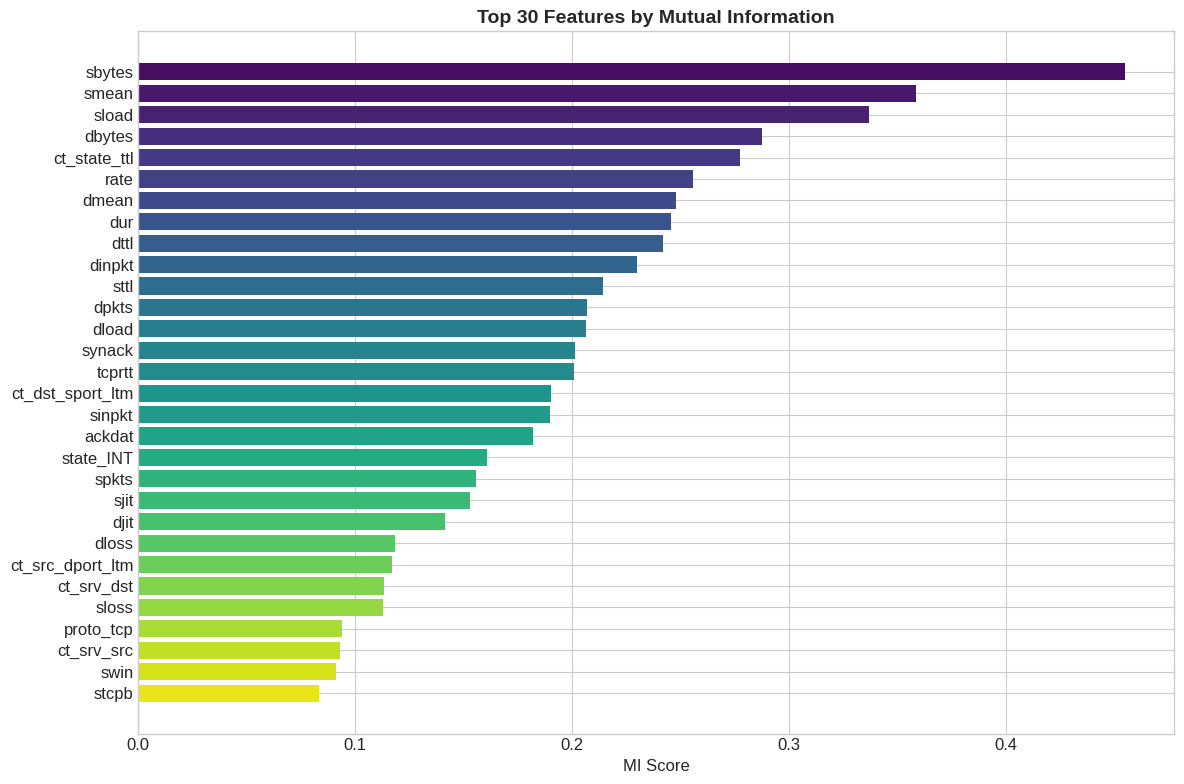

In [16]:
# ============================================================
# Feature Selection - Mutual Information
# ============================================================
TOP_K = 30

print(f"Computing mutual information scores for {X_train_processed.shape[1]} features...")
mi_scores = mutual_info_classif(
    X_train_processed, y_train_split, random_state=RANDOM_STATE, n_neighbors=5
)

mi_df = pd.DataFrame({
    'feature': all_feature_names,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

# Select top K features
selected_features = mi_df.head(TOP_K)['feature'].tolist()
selected_indices = [all_feature_names.index(f) for f in selected_features]

X_train_selected = X_train_processed[:, selected_indices]
X_val_selected = X_val_processed[:, selected_indices]
X_test_selected = X_test_processed[:, selected_indices]

print(f"\nSelected top {TOP_K} features by mutual information:")
for i, row in mi_df.head(TOP_K).iterrows():
    print(f"  {row['feature']}: {row['mi_score']:.4f}")

# Plot MI scores
fig, ax = plt.subplots(figsize=(12, 8))
top_mi = mi_df.head(TOP_K)
ax.barh(range(len(top_mi)), top_mi['mi_score'].values, color=sns.color_palette('viridis', TOP_K))
ax.set_yticks(range(len(top_mi)))
ax.set_yticklabels(top_mi['feature'].values)
ax.invert_yaxis()
ax.set_title(f'Top {TOP_K} Features by Mutual Information', fontsize=14, fontweight='bold')
ax.set_xlabel('MI Score')
plt.tight_layout()
plt.savefig('mutual_information_scores.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ============================================================
# Handle Class Imbalance - SMOTE
# ============================================================
print(f"Class distribution BEFORE SMOTE:")
print(f"  Normal: {(y_train_split == 0).sum():,}")
print(f"  Attack: {(y_train_split == 1).sum():,}")

smote = SMOTE(random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_selected, y_train_split)

print(f"\nClass distribution AFTER SMOTE:")
print(f"  Normal: {(y_train_resampled == 0).sum():,}")
print(f"  Attack: {(y_train_resampled == 1).sum():,}")
print(f"\nResampled training set shape: {X_train_resampled.shape}")

Class distribution BEFORE SMOTE:
  Normal: 30,488
  Attack: 37,353

Class distribution AFTER SMOTE:
  Normal: 37,353
  Attack: 37,353

Resampled training set shape: (74706, 30)


## 4. Model Training & Hyperparameter Tuning

In [18]:
# ============================================================
# Model Training Setup
# ============================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
training_log = []

def train_and_tune(name, estimator, param_dist, X, y):
    """Train a model with RandomizedSearchCV and return results."""
    print(f"\n{'='*60}")
    print(f"Training: {name}")
    print(f"{'='*60}")

    start_time = time.time()

    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_dist,
        n_iter=10,
        cv=cv,
        scoring='f1',
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1
    )
    search.fit(X, y)

    elapsed = time.time() - start_time

    print(f"\nBest CV F1 Score: {search.best_score_:.4f}")
    print(f"Best Parameters: {search.best_params_}")
    print(f"Training Time: {elapsed:.1f}s")

    training_log.append({
        'model': name,
        'best_cv_f1': search.best_score_,
        'best_params': str(search.best_params_),
        'training_time_s': round(elapsed, 1)
    })

    return search.best_estimator_

In [19]:
# ============================================================
# Algorithm A: Random Forest
# ============================================================
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced']
}

rf_model = train_and_tune(
    'Random Forest',
    RandomForestClassifier(random_state=RANDOM_STATE),
    rf_params,
    X_train_resampled, y_train_resampled
)


Training: Random Forest
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best CV F1 Score: 0.9540
Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': None, 'class_weight': 'balanced'}
Training Time: 776.5s


In [20]:
# ============================================================
# Algorithm B: XGBoost
# ============================================================
# Compute scale_pos_weight
n_neg = (y_train_resampled == 0).sum()
n_pos = (y_train_resampled == 1).sum()
scale_weight = n_neg / n_pos if n_pos > 0 else 1.0

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [6, 10],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_model = train_and_tune(
    'XGBoost',
    XGBClassifier(
        scale_pos_weight=scale_weight,
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        use_label_encoder=False
    ),
    xgb_params,
    X_train_resampled, y_train_resampled
)


Training: XGBoost
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best CV F1 Score: 0.9566
Best Parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.1}
Training Time: 110.1s


In [21]:
# ============================================================
# Algorithm C: Logistic Regression (Baseline)
# ============================================================
lr_params = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'class_weight': ['balanced']
}

lr_model = train_and_tune(
    'Logistic Regression',
    LogisticRegression(
        max_iter=1000, solver='lbfgs', random_state=RANDOM_STATE
    ),
    lr_params,
    X_train_resampled, y_train_resampled
)


Training: Logistic Regression
Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best CV F1 Score: 0.8638
Best Parameters: {'class_weight': 'balanced', 'C': 1.0}
Training Time: 14.5s


## 5. Model Evaluation & Comparison

In [22]:
# ============================================================
# Evaluate All Models on Validation Set
# ============================================================
models = {
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'Logistic Regression': lr_model
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_val_selected)
    y_proba = model.predict_proba(X_val_selected)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred),
        'Recall': recall_score(y_val, y_pred),
        'F1': f1_score(y_val, y_pred),
        'ROC-AUC': roc_auc_score(y_val, y_proba),
        'PR-AUC': average_precision_score(y_val, y_proba)
    })

results_df = pd.DataFrame(results)
print("\n" + "=" * 80)
print("MODEL COMPARISON (Validation Set)")
print("=" * 80)
print(results_df.to_string(index=False, float_format='{:.4f}'.format))

# Select best model
best_idx = results_df['F1'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
best_model = models[best_model_name]
print(f"\nBest Model: {best_model_name} (F1 = {results_df.loc[best_idx, 'F1']:.4f})")


MODEL COMPARISON (Validation Set)
              Model  Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC
      Random Forest    0.9498     0.9750  0.9328 0.9534   0.9912  0.9932
            XGBoost    0.9522     0.9745  0.9377 0.9557   0.9925  0.9943
Logistic Regression    0.8624     0.8800  0.8685 0.8742   0.9516  0.9620

Best Model: XGBoost (F1 = 0.9557)


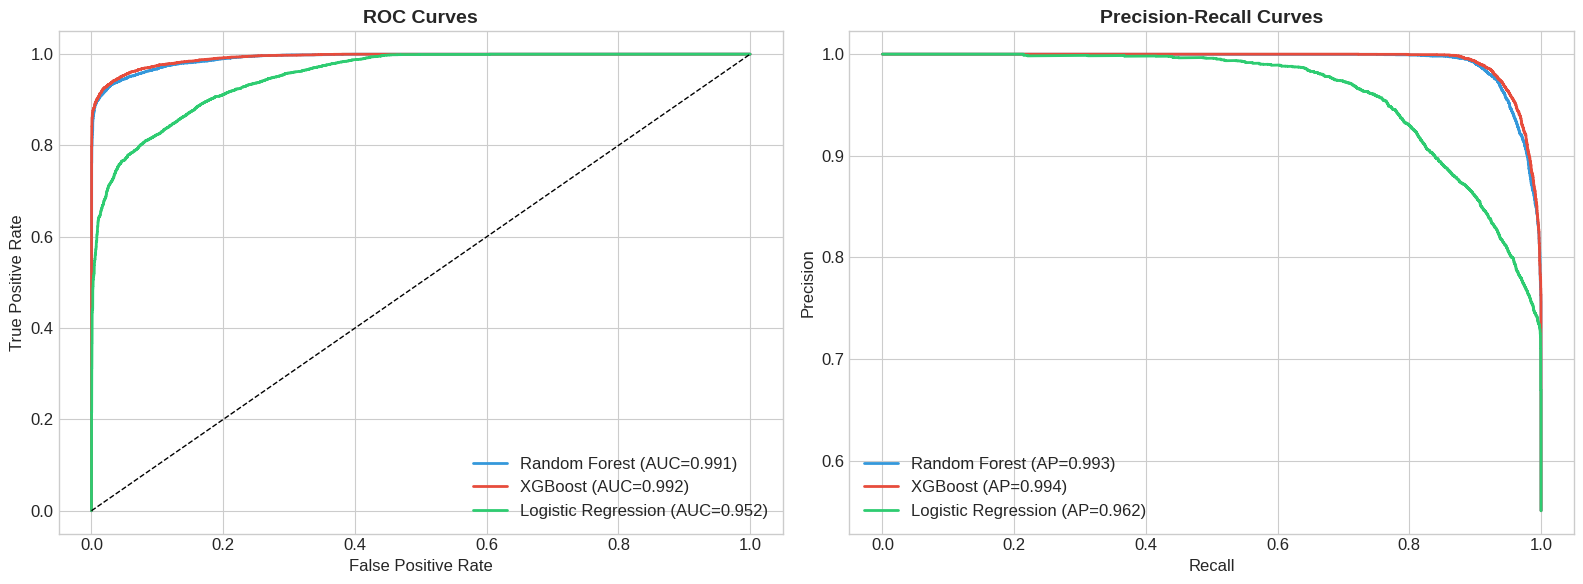

In [23]:
# ============================================================
# ROC Curves
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, (name, model) in enumerate(models.items()):
    y_proba = model.predict_proba(X_val_selected)[:, 1]

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    auc = roc_auc_score(y_val, y_proba)
    axes[0].plot(fpr, tpr, color=colors[i], lw=2, label=f'{name} (AUC={auc:.3f})')

    # PR Curve
    prec, rec, _ = precision_recall_curve(y_val, y_proba)
    ap = average_precision_score(y_val, y_proba)
    axes[1].plot(rec, prec, color=colors[i], lw=2, label=f'{name} (AP={ap:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_title('ROC Curves', fontsize=14, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

axes[1].set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

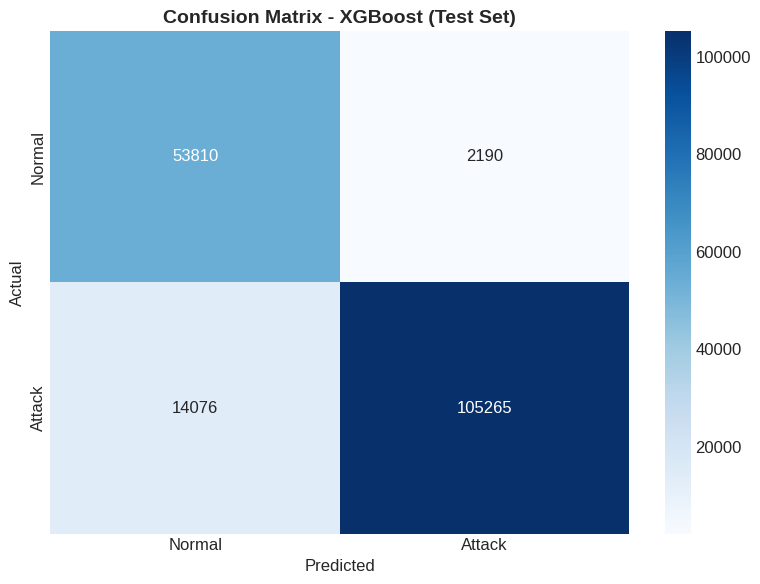


Test Set Classification Report (XGBoost):
              precision    recall  f1-score   support

      Normal       0.79      0.96      0.87     56000
      Attack       0.98      0.88      0.93    119341

    accuracy                           0.91    175341
   macro avg       0.89      0.92      0.90    175341
weighted avg       0.92      0.91      0.91    175341



In [24]:
# ============================================================
# Confusion Matrix - Best Model on Test Set
# ============================================================
y_test_pred = best_model.predict(X_test_selected)
y_test_proba = best_model.predict_proba(X_test_selected)[:, 1]

cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
ax.set_title(f'Confusion Matrix - {best_model_name} (Test Set)', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTest Set Classification Report ({best_model_name}):")
print(classification_report(y_test, y_test_pred, target_names=['Normal', 'Attack']))

## 6. Feature Importance

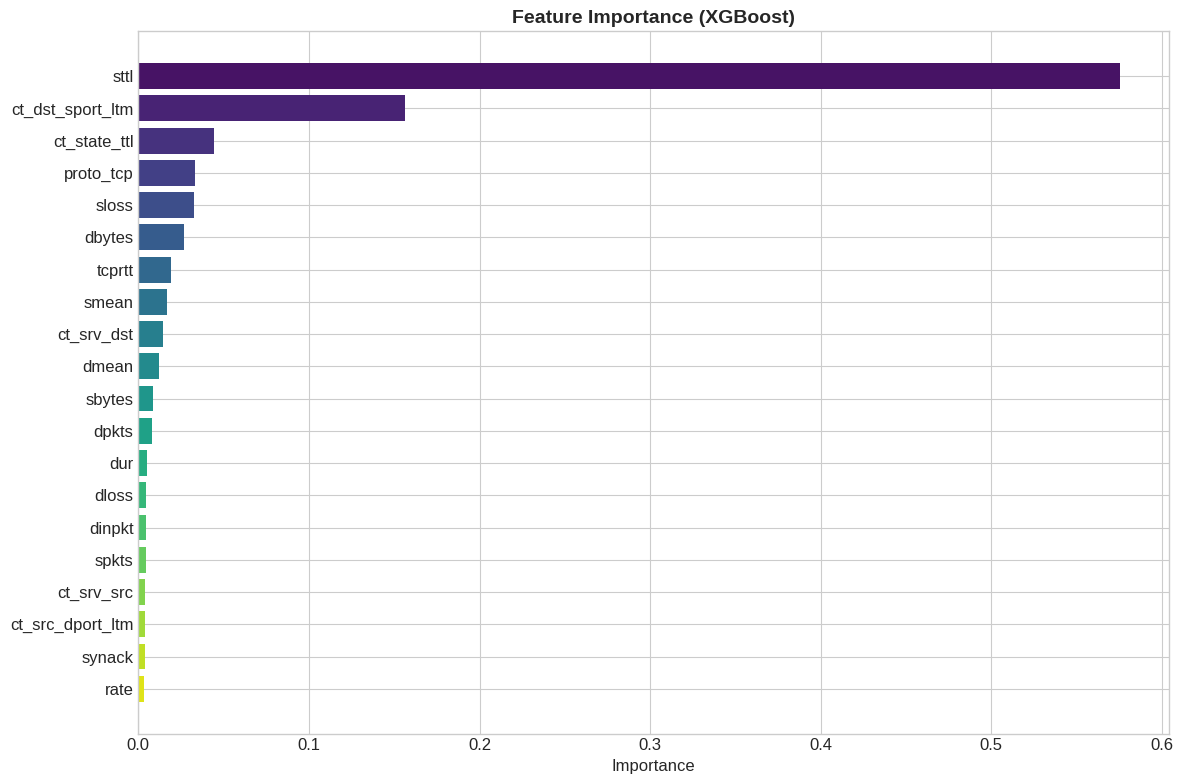


Top 10 Important Features:
  sttl: 0.5752
  ct_dst_sport_ltm: 0.1563
  ct_state_ttl: 0.0445
  proto_tcp: 0.0331
  sloss: 0.0326
  dbytes: 0.0266
  tcprtt: 0.0191
  smean: 0.0171
  ct_srv_dst: 0.0144
  dmean: 0.0120


In [25]:
# ============================================================
# Feature Importance - Best Model
# ============================================================
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feat_imp_df = pd.DataFrame({
        'feature': selected_features,
        'importance': importances
    }).sort_values('importance', ascending=False)

    fig, ax = plt.subplots(figsize=(12, 8))
    top_n = min(20, len(feat_imp_df))
    top_imp = feat_imp_df.head(top_n)
    ax.barh(range(top_n), top_imp['importance'].values, color=sns.color_palette('viridis', top_n))
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_imp['feature'].values)
    ax.invert_yaxis()
    ax.set_title(f'Feature Importance ({best_model_name})', fontsize=14, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\nTop 10 Important Features:")
    for i, row in feat_imp_df.head(10).iterrows():
        print(f"  {row['feature']}: {row['importance']:.4f}")
else:
    print("Best model does not have feature_importances_ attribute.")

In [26]:
# ============================================================
# Save Model Artifacts
# ============================================================
import datetime

ARTIFACTS_DIR = 'model_artifacts'
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

date_str = datetime.datetime.now().strftime('%Y%m%d')

# Save all models
joblib.dump(rf_model, os.path.join(ARTIFACTS_DIR, 'rf_model.pkl'))
joblib.dump(xgb_model, os.path.join(ARTIFACTS_DIR, 'xgb_model.pkl'))
joblib.dump(lr_model, os.path.join(ARTIFACTS_DIR, 'lr_model.pkl'))

# Save best model with versioned name
best_model_path = os.path.join(ARTIFACTS_DIR, f'best_model_v1.0_{date_str}.pkl')
joblib.dump(best_model, best_model_path)

# Save preprocessing pipeline
joblib.dump(preprocessor, os.path.join(ARTIFACTS_DIR, 'preprocessing_pipeline.pkl'))

# Save feature list
with open(os.path.join(ARTIFACTS_DIR, 'feature_list.txt'), 'w') as f:
    for feat in selected_features:
        f.write(f"{feat}\n")

# Save selected indices for evaluate_model.py
joblib.dump(selected_indices, os.path.join(ARTIFACTS_DIR, 'selected_indices.pkl'))

# Save training log
log_df = pd.DataFrame(training_log)
log_df.to_csv(os.path.join(ARTIFACTS_DIR, 'training_log.csv'), index=False)

# Save metadata
metadata = {
    'best_model_name': best_model_name,
    'selected_features': selected_features,
    'numerical_cols': numerical_cols,
    'categorical_cols': categorical_cols,
    'date': date_str
}
joblib.dump(metadata, os.path.join(ARTIFACTS_DIR, 'metadata.pkl'))

print(f"All artifacts saved to {ARTIFACTS_DIR}/")
print(f"Best model: {best_model_path}")
print(f"\nSaved files:")
for f in os.listdir(ARTIFACTS_DIR):
    size = os.path.getsize(os.path.join(ARTIFACTS_DIR, f))
    print(f"  {f}: {size/1024:.1f} KB")

All artifacts saved to model_artifacts/
Best model: model_artifacts/best_model_v1.0_20260802.pkl

Saved files:
  preprocessing_pipeline.pkl: 6.2 KB
  rf_model.pkl: 78280.2 KB
  best_model_v1.0_20260802.pkl: 2016.8 KB
  xgb_model.pkl: 2016.8 KB
  metadata.pkl: 0.6 KB
  selected_indices.pkl: 0.1 KB
  lr_model.pkl: 1.1 KB
  training_log.csv: 0.4 KB
  feature_list.txt: 0.2 KB


In [27]:
# ============================================================
# Download artifacts if on Colab
# ============================================================
if IN_COLAB:
    # Zip artifacts for download
    import shutil
    shutil.make_archive('model_artifacts', 'zip', '.', 'model_artifacts')
    files.download('model_artifacts.zip')
    print("\nDownload the model_artifacts.zip file to use with evaluate_model.py")
else:
    print("\nArtifacts saved locally. Run evaluate_model.py next.")

print("\n" + "=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Download the model_artifacts.zip file to use with evaluate_model.py

TRAINING COMPLETE
